In [179]:
# %pip install torch torchvision --index-url https://download.pytorch.org/whl/cu130
# %pip install scikit-learn torch.utils pandas matplotlib

# PyTorch Classification Mock Model w/ Credit Data
## (INTENDED) Goal

Build a classification model using `pytorch` upon the `Credit Risk Kaggle Dataset`. Through various steps, the data will be laundered, then put into `CreditRisk` classes. These will be put into `DataLoader`s and then interpreted by the classification model. The end goal is to determine whether or not an individual, based on given traits poses no credit risk (0) or is likely to default (1). 

## Tasks: 
1. **Setup & Data Loading:** 
    - Import `torch`, `pandas`, `sklearn`, and other dependencies.
    - Load in the dataset from `.csv`.
    - Check for cuda.

2. **Explore Data and Clean:**
    - Use `.info()`, `.describe()`, `.isnull()`, and other to find missing data/read data. 
    - Use `IterativeImputer` and/or `mean/median` to fill missing values within the dataset. 
    - Remove outliers that skew the data. i.e.: People with extensive employment lengths (60 years) or extreme age values (100 years)

3. **Feature Engineer and Preprocess Data**
    - Convert target from y/n to 1/0
    - Transform text features into numerical columns
    - Define features X and target y

4. **Data Splitting and Scaling:**
    - Split the data using `train_test_split` into training and testing sets (80/20) w/ random state (42)
    - Apply Standard Scaler to both feature sets to normalize the inputs

5. **PyTorch It!**
    - Convert numpy arrays into torch float tensors
    - Build `CreditDataset`
    - Use DataLoaders to create training and testing iterations with batch sizing

6. **Model Creation:**
    - Define your class with `nn.Linear`, `nn.ReLU`, `nn.Dropout`, and `nn.BatchNorm1d`
    - Initialize loss function. 
    - Set up Adam Optimizer with learning rate and weight decay

7. **Training Loop/Validation:**
    - Implement a training loop with the forward pass, loss calc, backprop, and weight updating
    - Check classification accuracy + loss during training
    - Check validation loss -> Check for overfitting

8. **Evaluation:**
    - Run the model in `eval()` mode. 
    - Generate performance report with Confusion matrix, Precision, recall, and f1-score

9. **Visualization + Analysis:**
    - Plot training vs validation loss over epochs
    - Visualize model mistakes through confusion heatmap

10. **Model Saving & Data Storage:**
    - Save using `torch.save()` to store the trained model weights
    - Save the `StandardScaler` using joblib to reuse it later on

## Setup & Data Loading
**Tasks:**
1. Import libraries
2. Check for Cuda availability
3. Load Credit Risk Dataset from `.csv` file within `../data/raw/`

In [180]:
import torch
import torch.nn as nn
import torch.optim as optim

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [181]:
# Check if Cuda is Available
torch.cuda.is_available()

# View Primary GPU
torch.cuda.get_device_name(0)

# Set default torch device to GPU (cuda)
torch.set_default_device('cuda')

In [182]:
# Reading the csv file
credit_risk_df = pd.read_csv("../data/raw/credit_risk_dataset.csv")

# Printing Top 5 Rows
print(credit_risk_df.head())
print("-------------------------------------------------------------------------------------------------------")

   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                           3  


## Explore Data 
**Tasks:**
1. Use `.info()`, `.describe()`, and `.isnull()` to find missing values within the dataframe

In [183]:
print(credit_risk_df.info())
print(credit_risk_df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB
None
         person_age  person_income  perso

In [184]:
# Shape and Size of the Data
print(credit_risk_df.size)
print(credit_risk_df.shape)

# Check for null values
print(credit_risk_df.isnull().sum())

390972
(32581, 12)
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


## Encode Features & Clean Data
**Tasks:**
1. Encode target variable with `LabelEncoder()`
2. Encode categorical features with `pd.get_dummies()`
3. Use `IsolationForest` to find and separate clear outliers

In [185]:
# First we must encode the target var
# We will use LabelEncoder from sklearn
lb_enc = LabelEncoder()

credit_risk_df['cb_person_default_on_file'] = lb_enc.fit_transform(credit_risk_df['cb_person_default_on_file'])
print(credit_risk_df['cb_person_default_on_file'])

0        1
1        0
2        0
3        0
4        1
        ..
32576    0
32577    0
32578    0
32579    0
32580    0
Name: cb_person_default_on_file, Length: 32581, dtype: int64


In [186]:
# Encode Categorical Features With get_dummies()

# Check datatypes of columns
print(credit_risk_df.dtypes)

# Select categorical columns via select_dtypes()
all_cat_cols = credit_risk_df.select_dtypes(include = ["category", "object", "str"]).columns.tolist()

# Check if the correct columns are there
print(all_cat_cols)

# encode and check
credit_risk_encoded_df = pd.get_dummies(credit_risk_df, columns = all_cat_cols, drop_first = True)
print(credit_risk_encoded_df)

person_age                      int64
person_income                   int64
person_home_ownership             str
person_emp_length             float64
loan_intent                       str
loan_grade                        str
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file       int64
cb_person_cred_hist_length      int64
dtype: object
['person_home_ownership', 'loan_intent', 'loan_grade']
       person_age  person_income  person_emp_length  loan_amnt  loan_int_rate  \
0              22          59000              123.0      35000          16.02   
1              21           9600                5.0       1000          11.14   
2              25           9600                1.0       5500          12.87   
3              23          65500                4.0      35000          15.23   
4              24          54400                8.0      35000        

In [187]:
# Secondary Check
print(credit_risk_df.query("person_emp_length > 60").count())

person_age                    2
person_income                 2
person_home_ownership         2
person_emp_length             2
loan_intent                   2
loan_grade                    2
loan_amnt                     2
loan_int_rate                 2
loan_status                   2
loan_percent_income           2
cb_person_default_on_file     2
cb_person_cred_hist_length    2
dtype: int64


In [188]:
# Use Isolation Forest
from sklearn.ensemble import IsolationForest

# Separate Features from Target
X_temporary = credit_risk_encoded_df.drop('cb_person_default_on_file', axis = 1)

iso_forest = IsolationForest(contamination = 0.01, random_state = 42)
inliers = iso_forest.fit_predict(X_temporary)

cleaned_credit_df = credit_risk_encoded_df[inliers == 1].reset_index(drop = True)

## Fill Gaps
**Tasks:**
1. Split data using `tts` from sklearn
2. Use `IterativeImputer` to fill in null values

In [189]:
# Thinking of iterative imputer

#Our imports
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

# Split the data
train_df, test_df = train_test_split(cleaned_credit_df, test_size=0.2, random_state = 42)

# Create imputer object
imputer = IterativeImputer(max_iter = 10, random_state = 42)

# Fill Train, Transform Both
filled_trained_df = imputer.fit_transform(train_df)
filled_test_df = imputer.transform(test_df)

# Convert backt o DataFrames and keep column names
train_df = pd.DataFrame(filled_trained_df, columns = cleaned_credit_df.columns)
test_df = pd.DataFrame(filled_test_df, columns = cleaned_credit_df.columns)

print(train_df, test_df)

       person_age  person_income  person_emp_length  loan_amnt  loan_int_rate  \
0            24.0        60000.0           3.000000     3200.0       7.140000   
1            25.0        48000.0           0.000000     3200.0      18.523627   
2            33.0       117300.0           3.000000    16000.0      15.990000   
3            22.0        80000.0           3.000000    20000.0      13.980000   
4            30.0        61000.0           2.000000     4000.0       7.900000   
...           ...            ...                ...        ...            ...   
25799        36.0        43776.0           6.412901     6000.0       7.880000   
25800        23.0        54860.0           0.000000     5000.0      14.170000   
25801        22.0        12000.0           0.000000     1000.0      13.570000   
25802        23.0       200000.0           0.000000     5000.0       7.430000   
25803        32.0        65000.0           6.000000     5600.0      11.580000   

       loan_status  loan_pe

In [190]:
print(test_df.info())
print(train_df.info())

# Seemingly no outliers
test_df.reset_index(inplace=True)
train_df.reset_index(inplace=True)

<class 'pandas.DataFrame'>
RangeIndex: 6451 entries, 0 to 6450
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_age                   6451 non-null   float64
 1   person_income                6451 non-null   float64
 2   person_emp_length            6451 non-null   float64
 3   loan_amnt                    6451 non-null   float64
 4   loan_int_rate                6451 non-null   float64
 5   loan_status                  6451 non-null   float64
 6   loan_percent_income          6451 non-null   float64
 7   cb_person_default_on_file    6451 non-null   float64
 8   cb_person_cred_hist_length   6451 non-null   float64
 9   person_home_ownership_OTHER  6451 non-null   float64
 10  person_home_ownership_OWN    6451 non-null   float64
 11  person_home_ownership_RENT   6451 non-null   float64
 12  loan_intent_EDUCATION        6451 non-null   float64
 13  loan_intent_HOMEIMPROVEMENT  

## Split and Scale Data
**Task:**
1. Split the data into `X_train, X_test, y_train, y_test`
2. Create `StandardScaler()` and scale features
3. Verify the shape of training data before pushing into tensors

In [191]:
X_train = train_df.drop('cb_person_default_on_file', axis = 1)
X_test = test_df.drop('cb_person_default_on_file', axis = 1)

y_train = train_df['cb_person_default_on_file']
y_test = test_df['cb_person_default_on_file']

In [192]:
# Using scaler object to scale Features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_train = y_train.values
y_test = y_test.values

In [193]:
# Confirm the shapes of the train/test values
# May need to unsqueeze target series
print(f"X_train_scaled Shape: {X_train_scaled.shape}")
print(f"X_test_scaled Shape: {X_test_scaled.shape}")
print(f"y_train Shape: {y_train.shape}")
print(f"y_test Shape: {y_test.shape}")

X_train_scaled Shape: (25804, 23)
X_test_scaled Shape: (6451, 23)
y_train Shape: (25804,)
y_test Shape: (6451,)


## PyTorch It!
**Task:**
1. Convert `train_test_split` variables into `torch.tensor()` objects
2. Unsqueeze `y_train` and `y_test` if necessary depending on their shapes
3. Create dataset class for torch objects
4. Initialize DataLoaders

In [194]:
# Torchifying Training set
X_train_tensor = torch.tensor(X_train_scaled, dtype = torch.float32)
y_train_tensor = torch.tensor(y_train, dtype = torch.float32).unsqueeze(1)

# Torchifying Testing set
X_test_tensor = torch.tensor(X_test_scaled, dtype = torch.float32)
y_test_tensor = torch.tensor(y_test, dtype = torch.float32).unsqueeze(1)

# Checking they are running on the correct Device (GPU)
print(X_train_tensor.device)

cuda:0


In [195]:
print(y_test_tensor.shape)
print(X_test_tensor.shape)

torch.Size([6451, 1])
torch.Size([6451, 23])


In [196]:
# Import Dataset and DataLoader
from torch.utils.data import Dataset, DataLoader

# Create Dataset Class
class CreditDataset(Dataset): 
    # Initializes class attributes features and target to be input features/target
    def __init__(self, features, target): 
        self.features = features
        self.target = target
    
    # Initializes function that returns the length of dataset
    def __len__(self): 
        return len(self.features)
    
    # Returns the pair of items features, target by index
    def __getitem__(self, idx): 
        return self.features[idx], self.target[idx]
    

In [197]:
# Create a generator for the DataLoaders on GPU
cuda_generator = torch.Generator(device = 'cuda')

In [198]:
# Initialize X, y pairs as dataset objects
train_dataset = CreditDataset(X_train_tensor, y_train_tensor)
test_dataset = CreditDataset(X_test_tensor, y_test_tensor)

# Create dataloaders for each dataset object
train_dl = DataLoader(train_dataset, batch_size = 1024, shuffle = True, generator = cuda_generator)
test_dl = DataLoader(test_dataset, batch_size = 1024, shuffle = False, generator = cuda_generator)

In [199]:
# Batch Testing
print("First batch from train_dl")

for batch_X, batch_y in train_dl: 
    print(f"Batch_X Shape: {batch_X.shape} \nBatch_y Shape: {batch_y.shape}")
    break

First batch from train_dl
Batch_X Shape: torch.Size([1024, 23]) 
Batch_y Shape: torch.Size([1024, 1])


## Define Neural Network
**Task:**
1. Create `CreditModel` class
2. Complete the `forward` pass and `nn.Sequential` network
3. Utilize `nn.ReLU` as activation function
4. Define input dimension and initialize model object as `credit_model`

In [200]:
class CreditModel(nn.Module): 
    def __init__(self, input_features): 
        super(CreditModel, self).__init__()

        self.network = nn.Sequential(
            # Heavy Lifting for the first two Linear iterations
            nn.Linear(input_features, 128),
            # Normalizes the features
            nn.BatchNorm1d(128),
            # Activates them by introducing non-linearity
            nn.ReLU(), 
            # Because we have 22 features outputting 128 output values, our matrix shape is 128 * 22, and has 2816 weight conenctions
            # We need to drop lots of these to ensure the neural network isn't learning from memorized data. 
            # This is like removing cards to reshuffle the deck
            nn.Dropout(0.3),

            # Once again, but the reduction to 64 functions means we need to remove less features, because we are collapsing quickly after incrementing size
            # There are still too many output values that some do need to be dropped
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(), 
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)
        )

    def forward(self, x): 
        
        # No need to introduce non-linearity because nn.Sequential did the heavy lifting by introducing it during the feature shuffling. 
        return self.network(x)

In [201]:
input_dim = X_train_tensor.shape[1]

credit_model = CreditModel(input_dim).to('cuda')

In [202]:
print("Model Architecture: ")
print(credit_model)

Model Architecture: 
CreditModel(
  (network): Sequential(
    (0): Linear(in_features=23, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=16, bias=True)
    (11): ReLU()
    (12): Linear(in_features=16, out_features=1, bias=True)
  )
)


## Define Loss Function and Optimizer
**Task:**
1. Instantiate loss function object (`BCEWithLogitsLoss()`)
2. Instantiate optimizer (`optim.Adam()`)

In [203]:
loss_function = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(credit_model.parameters(), lr = 0.0001, weight_decay=1e-5)

## Training Loop
**Tasks:**
1. Define epoch iterations
2. Write training loop iterating through `train_dl`
3. Print losses for epochs at 10% intervals

In [204]:
epochs = 300
losses = []

for epoch in range(epochs): 
    epoch_loss = 0.0
    batch_count = 0

    for batch_X, batch_y in train_dl: 
        # Zero the gradient
        optimizer.zero_grad()
        # Create Prediction
        target_prediction = credit_model(batch_X)
        # Calculate Loss
        loss = loss_function(target_prediction, batch_y)
        # Create Gradient
        loss.backward()
        # Adjust weights
        optimizer.step()
        # Add loss to epoch loss
        epoch_loss += loss.item()
        batch_count += 1

    # Append avg epoch loss to overall losses
    avg_epoch_loss = epoch_loss / batch_count
    losses.append(avg_epoch_loss)

    if (epoch + 1) % 30 == 0: 
        print(f"Epoch [{epoch + 1} / {epochs}], Loss: {losses[-1]:.4f}\nAverage Epoch Loss: {avg_epoch_loss:.4f}")
    
print("Training Complete")

Epoch [30 / 300], Loss: 0.2424
Average Epoch Loss: 0.2424
Epoch [60 / 300], Loss: 0.2385
Average Epoch Loss: 0.2385
Epoch [90 / 300], Loss: 0.2396
Average Epoch Loss: 0.2396
Epoch [120 / 300], Loss: 0.2374
Average Epoch Loss: 0.2374
Epoch [150 / 300], Loss: 0.2377
Average Epoch Loss: 0.2377
Epoch [180 / 300], Loss: 0.2361
Average Epoch Loss: 0.2361
Epoch [210 / 300], Loss: 0.2371
Average Epoch Loss: 0.2371
Epoch [240 / 300], Loss: 0.2366
Average Epoch Loss: 0.2366
Epoch [270 / 300], Loss: 0.2352
Average Epoch Loss: 0.2352
Epoch [300 / 300], Loss: 0.2341
Average Epoch Loss: 0.2341
Training Complete


In [205]:
# Bottleneck checking

devices = {param.device for param in credit_model.parameters()}
print(devices)

{device(type='cuda', index=0)}


## Evaluate & Visualize
**Tasks:**
1. Plot Training Loss 
2. Create and iterate through a testing loop. Ensure `model.eval()` and `with torch.no_grad()`
3. Create visualizations of Confusion Matricies, present F1_Score
4. Get Accuracy rating and classification report

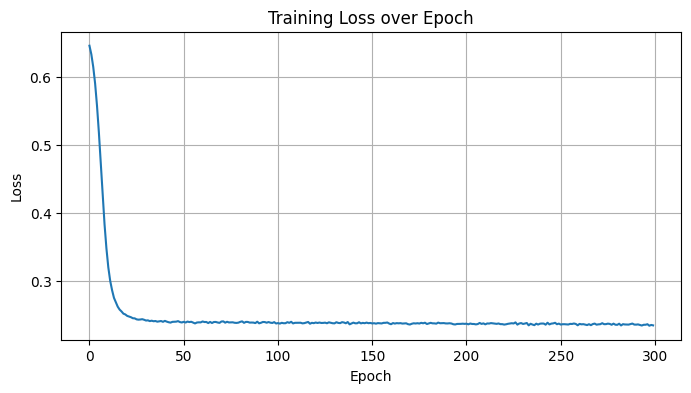

In [206]:
plt.figure(figsize = (8, 4))
plt.plot(losses)
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.title("Training Loss over Epoch")
plt.grid(True)
plt.show()

In [207]:
# Using a confusion matrix and F1 score to evaluate model 
from torchmetrics.classification import BinaryConfusionMatrix
from torchmetrics.classification import BinaryF1Score

bfs = BinaryF1Score()
bcm = BinaryConfusionMatrix()

In [208]:
credit_model.eval()

all_predictions = []
all_labels = []

with torch.no_grad(): 
    for batch_X, batch_y in test_dl: 
        outputs = credit_model(batch_X)

        probabilities = torch.sigmoid(outputs)
        bcm.update(probabilities, batch_y)
        bfs.update(probabilities, batch_y)

        preds = (probabilities > 0.5).float()

        all_predictions.extend(preds.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

final_cm = bcm.compute()
final_f1 = bfs.compute()

print("Testing Complete")

Testing Complete


Sklearn Final Accuracy: 0.8340

---------Classification Report---------
              precision    recall  f1-score   support

        Safe       0.91      0.89      0.90      5303
        Risk       0.53      0.59      0.56      1148

    accuracy                           0.83      6451
   macro avg       0.72      0.74      0.73      6451
weighted avg       0.84      0.83      0.84      6451



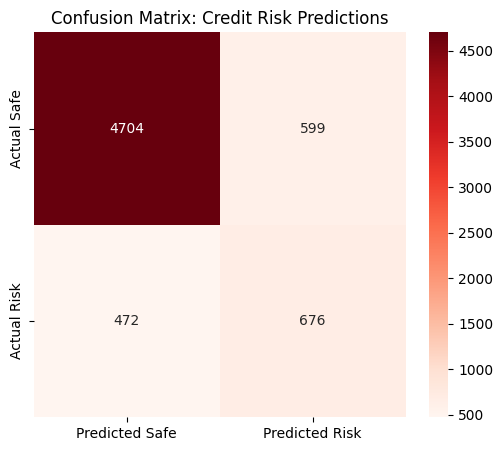

In [209]:
import seaborn as sns

# Going to compare confusion matricies between torchmetrics and sklearn metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Sklearn first
accuracy = accuracy_score(all_labels, all_predictions)
print(f"Sklearn Final Accuracy: {accuracy:.4f}")

print("\n---------Classification Report---------")
print(classification_report(all_labels, all_predictions, target_names=['Safe', 'Risk']))

con_ma = confusion_matrix(all_labels, all_predictions)
plt.figure(figsize=(6,5))
sns.heatmap(con_ma, annot = True, fmt = 'd', cmap = 'Reds', 
            xticklabels = ['Predicted Safe', 'Predicted Risk'],
            yticklabels = ['Actual Safe', 'Actual Risk'])

plt.title('Confusion Matrix: Credit Risk Predictions')
plt.show()

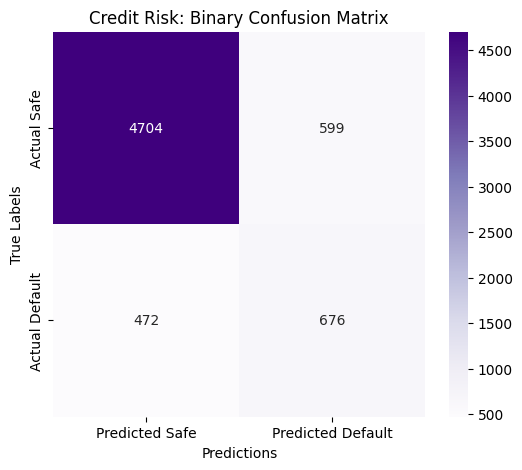

In [210]:
# PyTorch
conf_array = final_cm.cpu().numpy()

plt.figure(figsize=(6, 5))
sns.heatmap(conf_array, annot=True, fmt='g', cmap='Purples',
            xticklabels=['Predicted Safe', 'Predicted Default'],
            yticklabels=['Actual Safe', 'Actual Default'])
plt.xlabel('Predictions')
plt.ylabel('True Labels')
plt.title('Credit Risk: Binary Confusion Matrix')
plt.show()

In [212]:
print(f"Test Binary F1 Score: {final_f1:.4f}")

Test Binary F1 Score: 0.5580
